---

<center><h3></h3><h3><b>Comparação entre Vision Transformers e U-Net com MobileNetV2 na Segmentação de Exsudatos Lipídicos em Imagens de Retinografia

</b></h3></center>

Este notebook apresenta a análise das metodologias de segmentação de imagens de fundo de olho no diagnóstico de retinopatia diabética, como resultado do projeto final do Trabalho de Conclusão de Curso em Engenharia Elétrica pela Universidade Federal do Ceará (UFC).

Autor: Pedro Florencio

---



<!-- Python -->
<a href="https://www.python.org/downloads/release/python-3100/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/python-3.10-green" alt="Python Version" title="Python Version" height="20">
</a>

<!-- TensorFlow -->
<a href="https://www.tensorflow.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/TensorFlow-2.x-FF6F00?logo=tensorflow&logoColor=white" alt="TensorFlow" title="TensorFlow" height="20">
</a>

<!-- OpenCV -->
<a href="https://opencv.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/OpenCV-4.x-blue?logo=opencv&logoColor=white" alt="OpenCV" title="OpenCV" height="20">
</a>

<!-- scikit-image -->
<a href="https://scikit-image.org/" style="margin-right:12px;">
  <img align="left" src="https://img.shields.io/badge/scikit--image-0.21-orange?logo=scikit-learn&logoColor=white" alt="scikit-image" title="scikit-image" height="20">
</a>

<!-- Licença Creative Commons -->
<a href="https://creativecommons.org/licenses/by-nd/4.0/" target="_blank" style="margin-right:12px;">
  <img align="left" src="https://licensebuttons.net/l/by-nd/4.0/88x31.png" alt="Creative Commons BY-ND 4.0" title="Creative Commons BY-ND 4.0" height="20">
</a>

In [ ]:
# GPU
!nvidia-smi

# CPU
!cat /proc/cpuinfo | grep "model name" | uniq

# Memória RAM
!cat /proc/meminfo | grep MemTotal

Mon Jan 12 02:22:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### **1. Bibliotecas**


In [ ]:
!pip install -q Pillow
!pip install -q tensorflow
!pip install -q opencv-python
!pip install -q git+https://github.com/tensorflow/examples.git

  Preparing metadata (setup.py) ... done


In [ ]:
import os
import glob
import time
import keras
import cv2 as cv
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from google.colab import drive
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tensorflow_examples.models.pix2pix import pix2pix

drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


#### **2. Aquisição das Imagens**

Etapas no processo de aquisição da imagem:
- Passo 1: Leitura do arquivo da imagem;
- Passo 2: Decodificação da imagem em 3 canais para construção de uma matriz;
- Passo 3: Aplicando intervalo de 0 a 1;
- Passo 4: Redimensionamento da imagem;
- Passo 5: Leitura da máscara;
- Passo 6: Criação da matriz com 1 canal
- Passo 7: Redimensionamento da máscara com método Nearest
- Passo 8: Binarização da máscara

**Constantes**

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 4
FOLDER = '/gdrive/MyDrive/Lumina/'

##### **2.1. Conversão das máscaras de .TIF para .PNG**

In [ ]:
caminho_tif_train = FOLDER + 'Data/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/'
arquivos_tif_train = glob.glob(os.path.join(caminho_tif_train, "*.tif"))
caminho_tif_test = FOLDER + 'Data/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/3. Hard Exudates/'
arquivos_tif_test = glob.glob(os.path.join(caminho_tif_test, "*.tif"))

print(f"Encontradas {len(arquivos_tif_train)} máscaras de treino e {len(arquivos_tif_test)} máscaras de teste .tif para converter.")

for arquivo in arquivos_tif_train:
    try:
        img = Image.open(arquivo)
        novo_nome = arquivo.replace(".tif", ".png")
        img.save(novo_nome, "PNG")
        # os.remove(arquivo)

    except Exception as e:
        print(f"Erro ao converter {arquivo}: {e}")

for arquivo in arquivos_tif_test:
    try:
        img = Image.open(arquivo)
        novo_nome = arquivo.replace(".tif", ".png")
        img.save(novo_nome, "PNG")
        # os.remove(arquivo)

    except Exception as e:
        print(f"Erro ao converter {arquivo}: {e}")

print("Conversão concluída!")

Encontradas 54 máscaras de treino e 27 máscaras de teste .tif para converter.
Conversão concluída!


##### **2.2. Listas de caminhos dos arquivos**

<mark>Treino

In [ ]:
train_img_paths = sorted(glob.glob(FOLDER + 'Data/A. Segmentation/1. Original Images/a. Training Set/*.jpg'))
train_mask_paths = sorted(glob.glob(FOLDER + 'Data/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates/*.png'))

print(f"Imagens encontradas: {len(train_img_paths)}")
print(f"Máscaras encontradas: {len(train_mask_paths)}")

Imagens encontradas: 54
Máscaras encontradas: 54


<mark>Teste

In [ ]:
test_img_paths = sorted(glob.glob(FOLDER + 'Data/A. Segmentation/1. Original Images/b. Testing Set/*.jpg'))
test_mask_paths = sorted(glob.glob(FOLDER + 'Data/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/3. Hard Exudates/*.png'))

print(f"Imagens encontradas: {len(test_img_paths)}")
print(f"Máscaras encontradas: {len(test_mask_paths)}")

Imagens encontradas: 27
Máscaras encontradas: 27


##### **2.3. Carregamento e processamento das imagens**

In [ ]:
def load_and_preprocess(img_path, mask_path):

    # carregamento e processamento da imagem
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # carregamento e processamento da mascara
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method='nearest')
    mask = tf.cast(mask > 0, tf.int32)

    return img, mask

##### **2.4. Formato de Tensorflow Dataset**

In [ ]:
dataset_train = tf.data.Dataset.from_tensor_slices(
    (train_img_paths, train_mask_paths)
)

dataset_train = dataset_train.map(
    load_and_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset_train = dataset_train.shuffle(1000)
dataset_train = dataset_train.batch(BATCH_SIZE)
dataset_train = dataset_train.prefetch(tf.data.AUTOTUNE)

dataset_test = tf.data.Dataset.from_tensor_slices(
    (test_img_paths, test_mask_paths)
)

dataset_test = dataset_test.map(
    load_and_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset_test = dataset_test.batch(BATCH_SIZE)
dataset_test = dataset_test.prefetch(tf.data.AUTOTUNE)

#### **3. Visualização das Imagens**

Visualizando de imagem exemplo de fundo de olho do dataset

In [ ]:
FIGSIZE = (8,8)

In [ ]:
def display(display_list, main_title=None):
  plt.figure(figsize=FIGSIZE)

  title = ['Amostra', 'Ground-Truth', 'Máscara Predita']

  for i in range(len(display_list)):
    plt.subplot(1,len(display_list),i+1)
    plt.title(title[i],{'fontsize':10})
    plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
    plt.axis('off')

  plt.show()

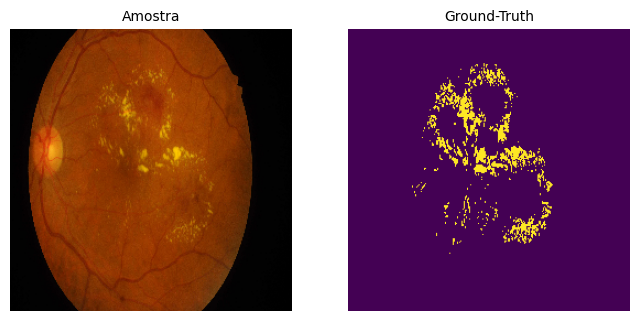

In [ ]:
for image, mask in dataset_test.take(1):
    sample_image, sample_mask = image[0], mask[0]
    display([sample_image, sample_mask])

#### **4. Data Augmentation**


##### **4.1. Inversão das imagens**

In [ ]:
@tf.function
def load_image_train(input_image, input_mask):
  input_image = tf.image.resize(input_image, (IMG_SIZE, IMG_SIZE))
  input_mask = tf.image.resize(input_mask, (IMG_SIZE, IMG_SIZE), method='nearest')

  if tf.random.uniform(()) > 0.5:
    input_image = tf.image.flip_left_right(input_image)
    input_mask = tf.image.flip_left_right(input_mask)

  return input_image, input_mask

In [ ]:
def load_image_test(input_image, input_mask):
  input_image = tf.image.resize(input_image, (IMG_SIZE, IMG_SIZE))
  input_mask = tf.image.resize(input_mask, (IMG_SIZE, IMG_SIZE))

  return input_image, input_mask

In [ ]:
TRAIN_LENGTH = len(train_img_paths)
BUFFER_SIZE = TRAIN_LENGTH
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

#### **5. Definição de treino e teste**

In [ ]:
train = dataset_train.map(load_image_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)
test = dataset_test.map(load_image_test)

In [ ]:
train_dataset = train
test_dataset = test

In [ ]:
print("Verificando o shape de um batch:")
for img, mask in train_dataset.take(1):
    print(f"Shape esperado: (4, 128, 128, 3)")
    print(f"Shape real:     {img.shape}")

Verificando o shape de um batch:
Shape esperado: (4, 128, 128, 3)
Shape real:     (4, 256, 256, 3)


#### **6. Modelagem**

##### **6.1. Definição da UNet Modificada**

In [ ]:
# quantidade de canais (ou classes) de saida
OUTPUT_CHANNELS = 1

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[IMG_SIZE, IMG_SIZE, 3], include_top=False)

# Use as ativações dessas camadas
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
layers = [base_model.get_layer(name).output for name in layer_names]

# Crie o modelo de extração de características
down_stack = tf.keras.Model(inputs=base_model.input, outputs=layers)

for layer in down_stack.layers[-30:]:
    layer.trainable = True

/tmp/ipython-input-3095245700.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=[IMG_SIZE, IMG_SIZE, 3], include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

In [ ]:
def unet_model(output_channels):

  last = tf.keras.layers.Conv2DTranspose(
      output_channels, 3, strides=2,
      padding='same', activation='sigmoid')

  inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])
  x = inputs

  skips = down_stack(x)
  x = skips[-1]
  skips = reversed(skips[:-1])

  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

##### **6.2. Métricas de avaliação**

In [ ]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return 1 - (2. * intersection + smooth) / (union + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return (2. * intersection + smooth) / (union + smooth)

In [ ]:
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true + y_pred) - intersection

    return (intersection + smooth) / (union + smooth)

In [ ]:
def focal_loss(y_true, y_pred, alpha=0.8, gamma=2):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)

    pt = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
    return -tf.reduce_mean(alpha * tf.pow(1-pt, gamma) * tf.math.log(pt))

def focal_dice_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

##### **6.3. Treinamento**

In [ ]:
model = unet_model(OUTPUT_CHANNELS)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_dice_loss,
    metrics=[dice_coef, iou_metric]
)

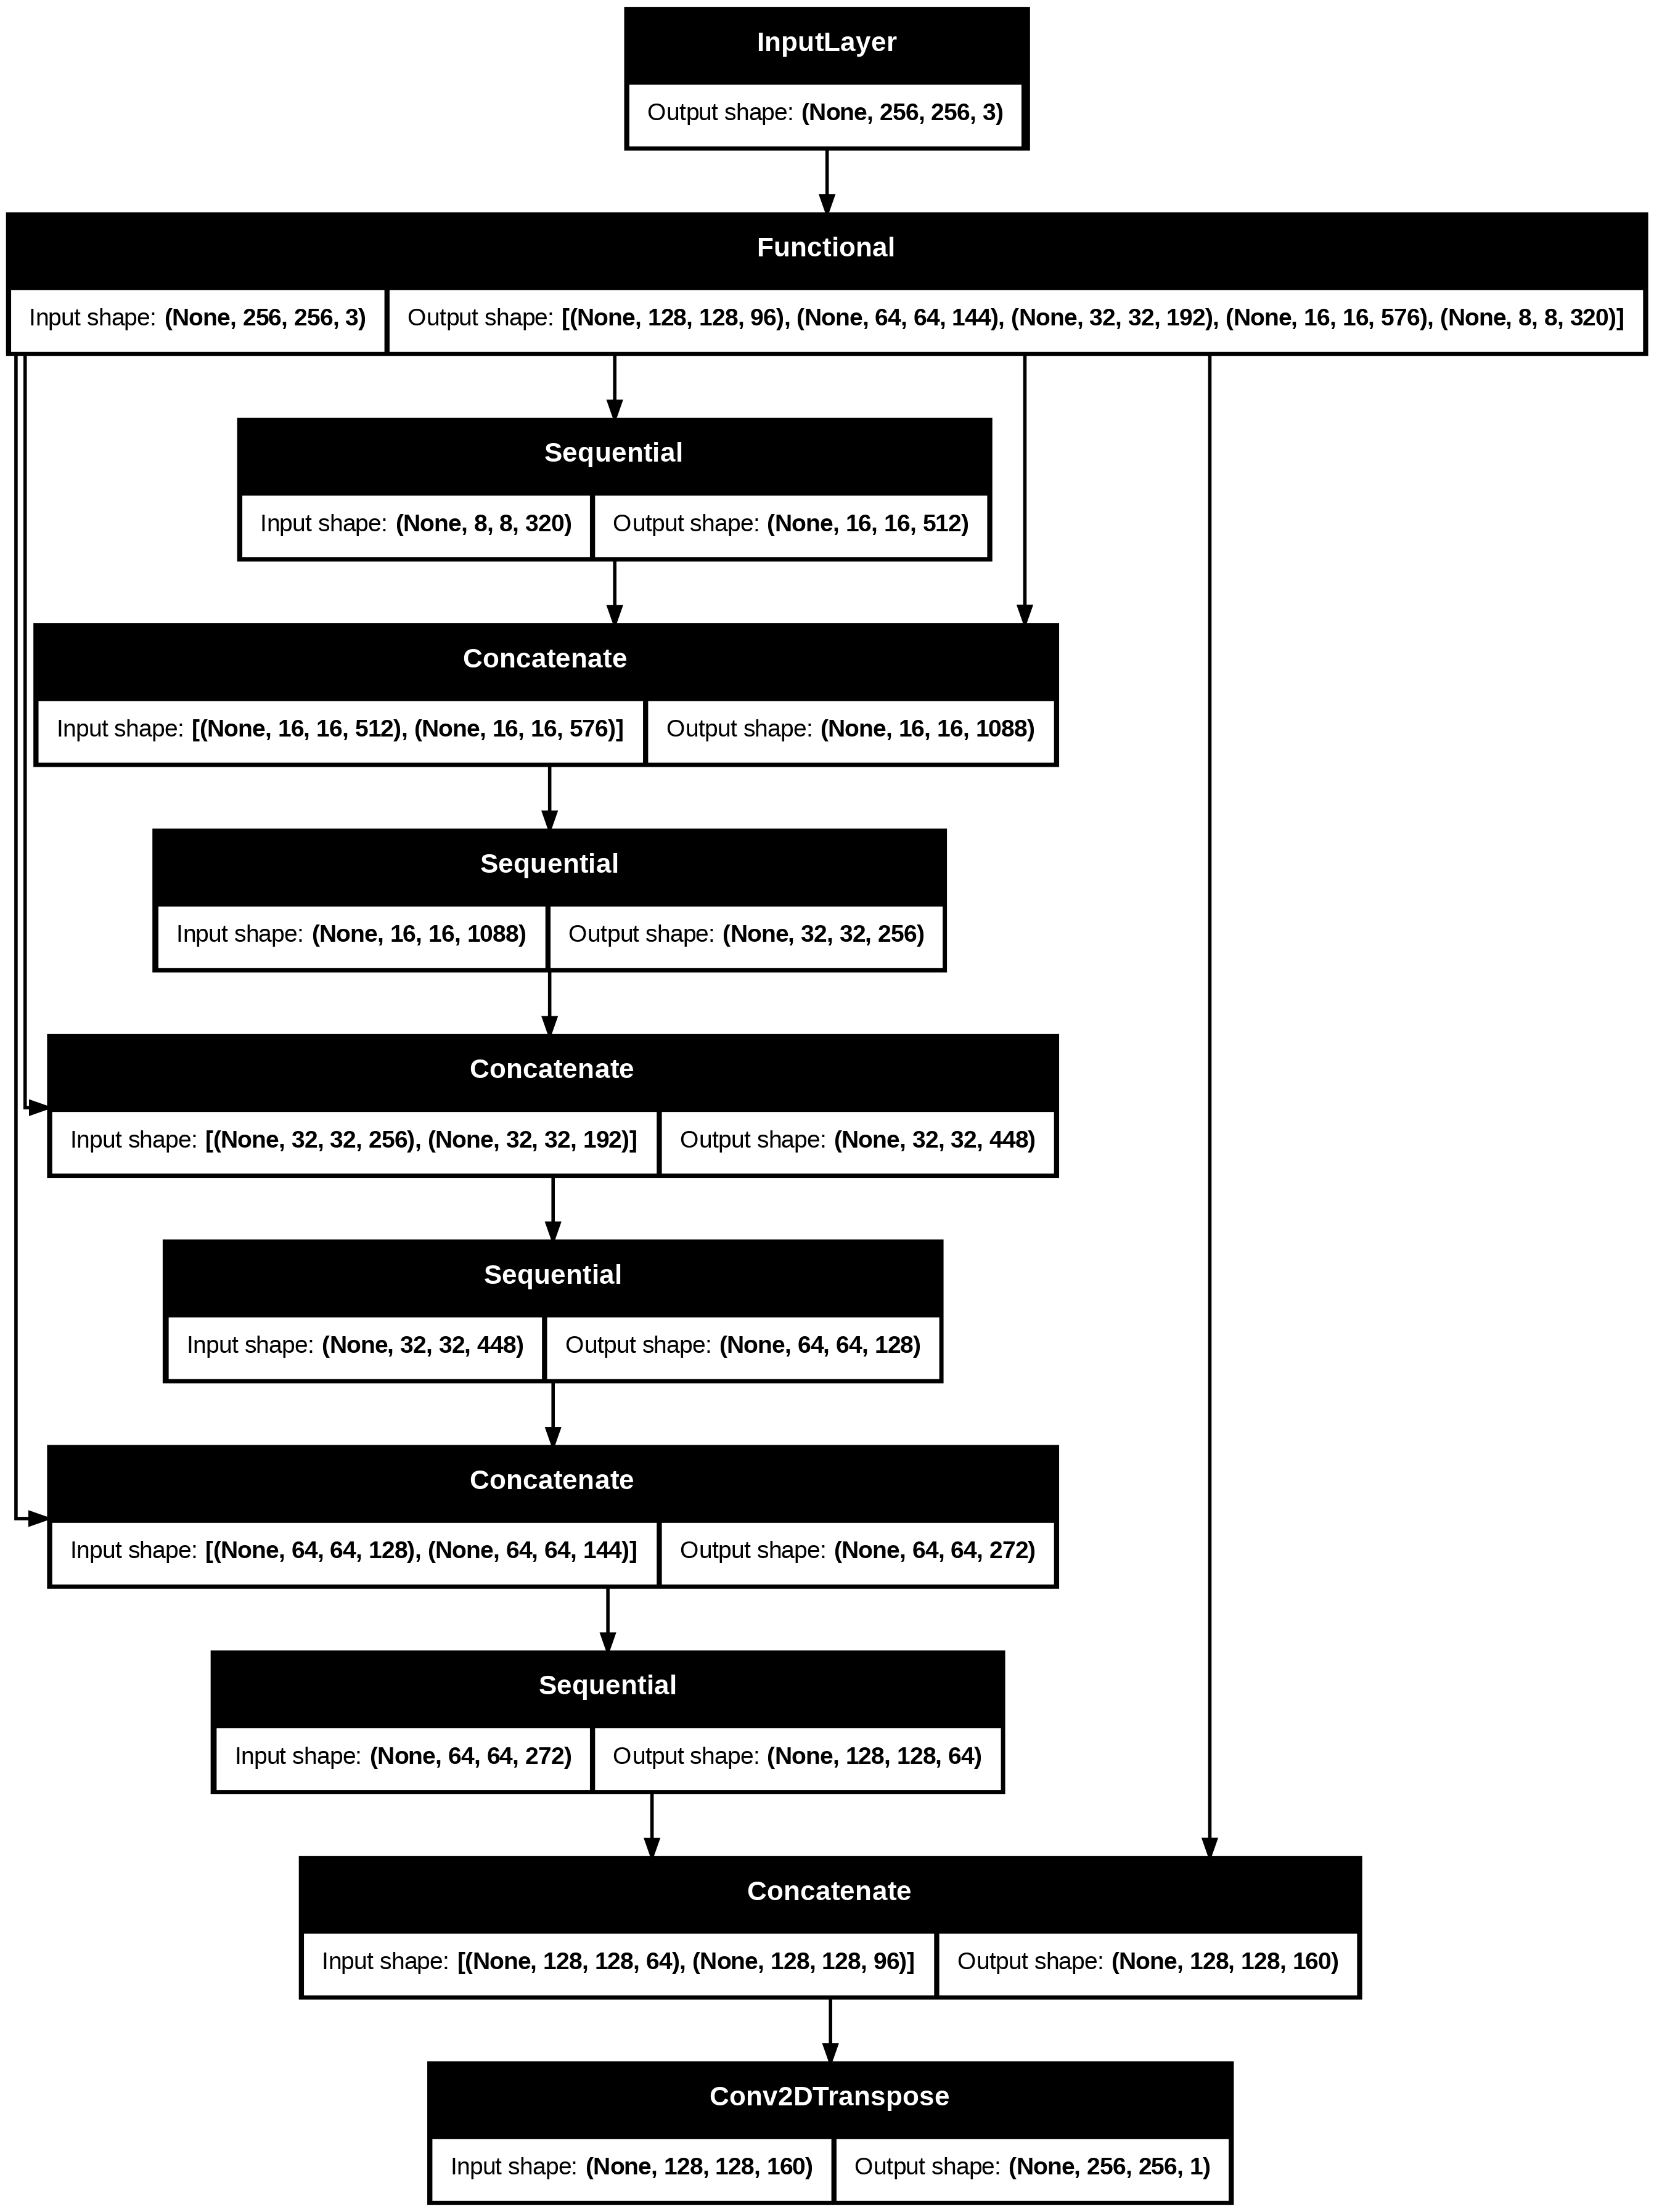

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

##### **6.3. Visualização antes do treinamento**

In [ ]:
def create_mask(pred_mask):
    pred_mask = (pred_mask > 0.5)
    return pred_mask[0]

In [ ]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step


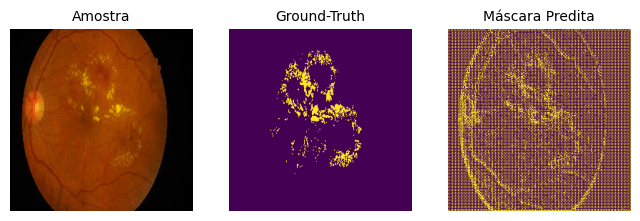

In [ ]:
show_predictions()

#### **7. Resultados**

##### **7.1. Visualização**

In [ ]:
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

In [ ]:
EPOCHS = 100
VALIDATION_STEPS = None

In [ ]:
for img, mask in train_dataset.take(1):
    pred = model(img)
    print(pred.shape)
    print(mask.shape)
    print(pred.dtype, mask.dtype)

(4, 256, 256, 1)
(4, 256, 256, 1)
<dtype: 'float32'> <dtype: 'int32'>


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # observa a perda de validação
    patience=5,              # quantas épocas esperar sem melhora
    restore_best_weights=True # volta para o melhor modelo
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


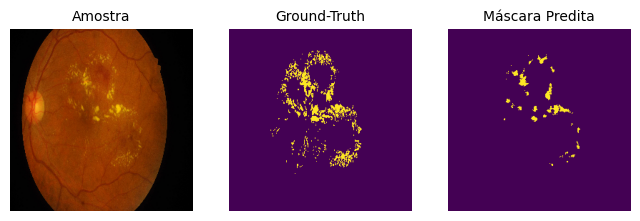


Sample Prediction after epoch 51

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - dice_coef: 0.5581 - iou_metric: 0.3907 - loss: 0.5991 - val_dice_coef: 0.2499 - val_iou_metric: 0.1461 - val_loss: 0.8200
CPU times: user 8min 26s, sys: 1min 4s, total: 9min 31s
Wall time: 8min 37s


In [ ]:
%%time
model_history = model.fit(train_dataset,
                          epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_dataset,
                          callbacks=[DisplayCallback(),early_stopping])

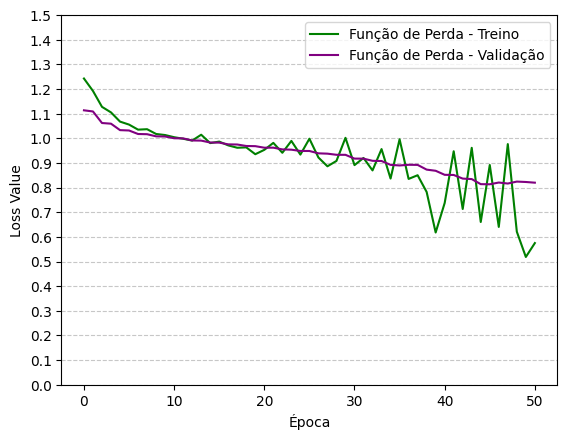

In [ ]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

# Ajusta o número de épocas para o número real de épocas treinadas
epochs = range(len(loss))

plt.figure()
plt.plot(epochs, loss, 'g', label='Função de Perda - Treino')
plt.plot(epochs, val_loss, 'purple', label='Função de Perda - Validação')
plt.title('')
plt.yticks(np.arange(0, 1.51, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Loss Value')
plt.legend()
plt.show()

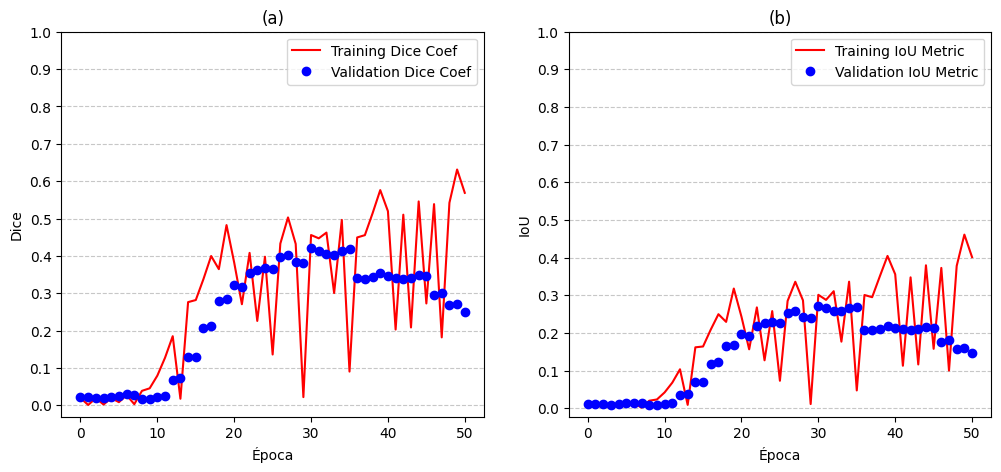

In [ ]:
dice = model_history.history['dice_coef']
val_dice = model_history.history['val_dice_coef']
iou = model_history.history['iou_metric']
val_iou = model_history.history['val_iou_metric']

epochs = range(len(dice))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, dice, 'r', label='Training Dice Coef')
plt.plot(epochs, val_dice, 'bo', label='Validation Dice Coef')
plt.title('(a)')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, iou, 'r', label='Training IoU Metric')
plt.plot(epochs, val_iou, 'bo', label='Validation IoU Metric')
plt.title('(b)')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('IoU')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


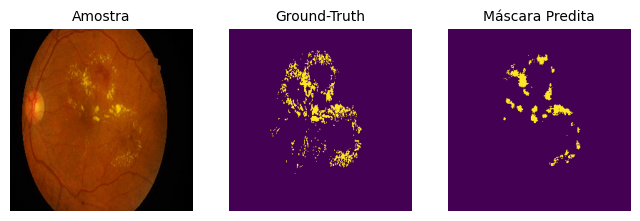

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


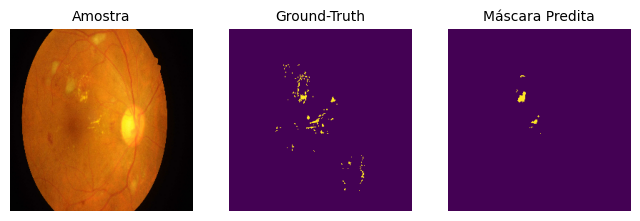

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


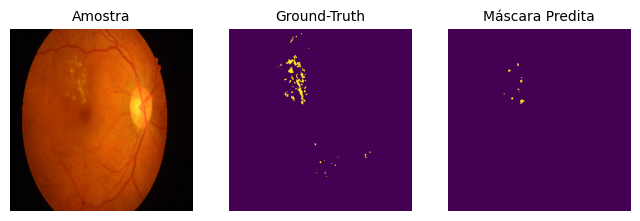

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


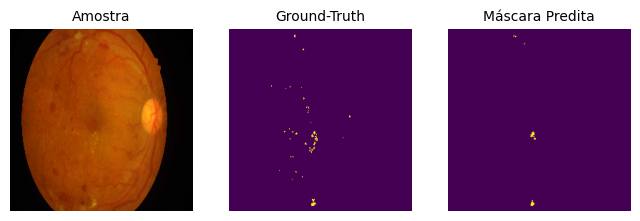

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


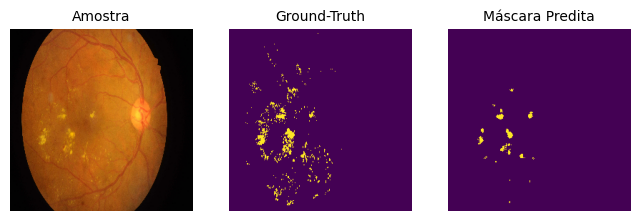

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


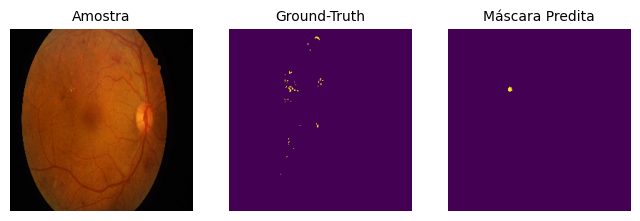

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


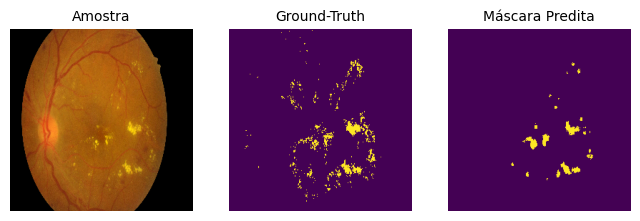

In [ ]:
show_predictions(test_dataset, 7)

##### **7.2. Avaliação**

In [ ]:
def dice_score(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


def iou_score(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [ ]:
def pixel_accuracy(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    correct = tf.equal(y_true, y_pred)
    return tf.reduce_mean(tf.cast(correct, tf.float32))

In [ ]:
def evaluate_segmentation_metrics(model, dataset):
    dice_list = []
    iou_list = []
    acc_list = []

    for x, y_true in dataset:
        y_pred = model(x, training=False)

        dice_list.append(dice_score(y_true, y_pred).numpy())
        iou_list.append(iou_score(y_true, y_pred).numpy())
        acc_list.append(pixel_accuracy(y_true, y_pred).numpy())

    return {
        "dice_mean": np.mean(dice_list),
        "dice_std": np.std(dice_list),
        "iou_mean": np.mean(iou_list),
        "iou_std": np.std(iou_list),
        "acc_mean": np.mean(acc_list),
        "acc_std": np.std(acc_list),
    }

In [ ]:
def measure_inference_time(model, dataset, n_batches=20):
    times = []

    for i, (x, _) in enumerate(dataset.take(n_batches)):
        start = time.time()
        _ = model(x, training=False)
        times.append(time.time() - start)

    return {
        "time_mean": np.mean(times),
        "time_std": np.std(times)
    }

In [ ]:
def estimate_energy_consumption(
    inference_time_sec,
    avg_power_watts=50  # ajuste conforme CPU/GPU
):
    # Energia = Potência × Tempo
    energy_joules = avg_power_watts * inference_time_sec
    return energy_joules

In [ ]:
def full_model_analysis(model, dataset, power_watts=50):
    metrics = evaluate_segmentation_metrics(model, dataset)
    timing = measure_inference_time(model, dataset)

    energy = estimate_energy_consumption(
        timing["time_mean"],
        avg_power_watts=power_watts
    )

    return {
        "Dice": f"{metrics['dice_mean']:.4f} ± {metrics['dice_std']:.4f}",
        "IoU": f"{metrics['iou_mean']:.4f} ± {metrics['iou_std']:.4f}",
        "Accuracy": f"{metrics['acc_mean']:.4f} ± {metrics['acc_std']:.4f}",
        "Inference time (s)": f"{timing['time_mean']:.4f} ± {timing['time_std']:.4f}",
        "Energy (J)": f"{energy:.2f}"
    }

In [ ]:
results = full_model_analysis(
    model,
    test_dataset,
    power_watts=50  # ajuste conforme sua máquina
)

for k, v in results.items():
    print(f"{k}: {v}")

Dice: 0.3452 ± 0.1018
IoU: 0.2132 ± 0.0750
Accuracy: 0.9911 ± 0.0053
Inference time (s): 0.2491 ± 0.0524
Energy (J): 12.46


**Deus é bom o tempo todo!**